In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\kumar\OneDrive\Documents\GitHub\PyHack-May2026\cleaned_data.csv")
df.head()


,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,2020-01-17 00:00:00,40.00,15.04,96.37,8.0,0.035,0.0,1.0,HUPA0023P,74,Female,Black,5.1,6.8,40
1,2020-01-17 00:05:00,41.33,8.32,91.40,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40
2,2020-01-17 00:10:00,42.67,7.58,85.99,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40
3,2020-01-17 00:15:00,44.00,7.34,82.43,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40
4,2020-01-17 00:20:00,50.00,7.58,78.82,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40


In [6]:
df.columns

Index(['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate',
       'bolus_volume_delivered', 'carb_input', 'Patient_ID', 'Age', 'Gender',
       'Race', 'Average Sleep Duration (hrs)', 'Sleep Quality (1-10)',
       '% with Sleep Disturbances'],
      dtype='str')

How does the average glucose level vary across different age groups?**

This analysis groups participants into four age categories:

- **0–19 years**  
- **20–39 years**  
- **40–59 years**  
- **60+ years**

For each age group, the mean glucose level is calculated to observe how glucose trends change with age.  
A bar chart is used to visualize these differences clearly.

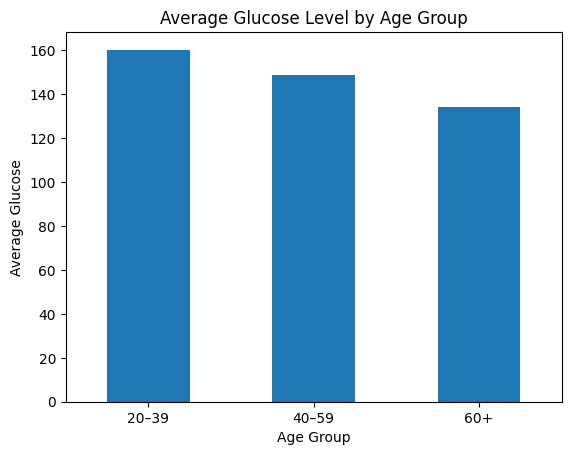

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Create age groups
bins = [0, 19, 39, 59, 120]
labels = ['0–19', '20–39', '40–59', '60+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Group by age and calculate mean glucose
age_glucose = df.groupby('Age_Group')['glucose'].mean()

# Plot
age_glucose.plot(kind='bar')
plt.title('Average Glucose Level by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Glucose')
plt.xticks(rotation=0)
plt.show()

How do different heart rate groups contribute to total calories burned?**

This visualization uses a **manual waterfall-style bar chart** to show how each heart rate group adds to the cumulative calories burned.  
Instead of a standard bar chart, each bar is stacked on top of the previous one using a running total, helping illustrate incremental contributions.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Create heart rate bins
bins = [0, 60, 80, 100, 120, 200]
labels = ['<60', '60–80', '80–100', '100–120', '120+']

df['HR_Group'] = pd.cut(df['heart_rate'], bins=bins, labels=labels)

# Mean calories per group
calories_by_hr = df.groupby('HR_Group')['calories'].mean().dropna()

In [10]:
base = calories_by_hr.iloc[0]
changes = calories_by_hr - base

values = [base] + list(changes[1:])
labels = calories_by_hr.index

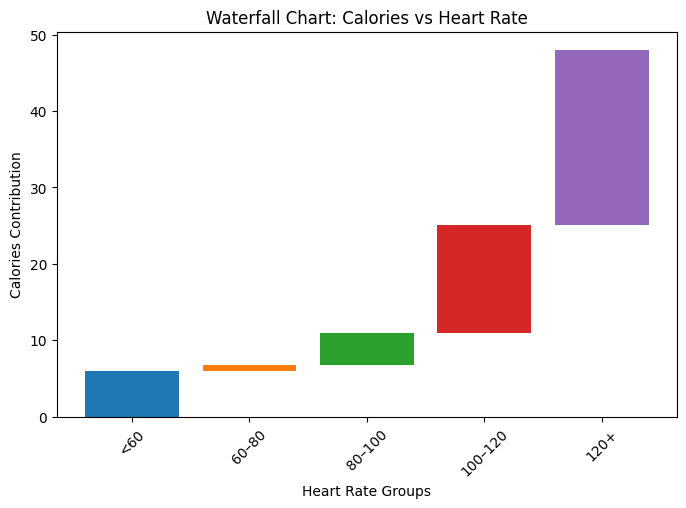

In [11]:
plt.figure(figsize=(8,5))

running_total = 0

for i, v in enumerate(values):
    plt.bar(labels[i], v, bottom=running_total)
    running_total += v

plt.title("Waterfall Chart: Calories vs Heart Rate")
plt.xlabel("Heart Rate Groups")
plt.ylabel("Calories Contribution")
plt.xticks(rotation=45)
plt.show()

In [14]:
import pandas as pd

gender_race_glucose = df.pivot_table(
    values='glucose',
    index='Race',
    columns='Gender',
    aggfunc='mean'
)

print(gender_race_glucose)

Gender               Female        Male
Race                                   
Asian                   NaN  151.222702
Black            130.969434  135.621937
Hispanic         200.795243  159.388017
Native American  160.184772  144.504224
Other            172.106522  147.306873
White                   NaN  184.216012


How does average glucose vary across Gender and Race?**

This analysis compares the **mean glucose levels** across combined demographic groups of **Gender** and **Race**.  
By grouping participants by both attributes, we can observe whether certain demographic combinations show higher or lower glucose levels.

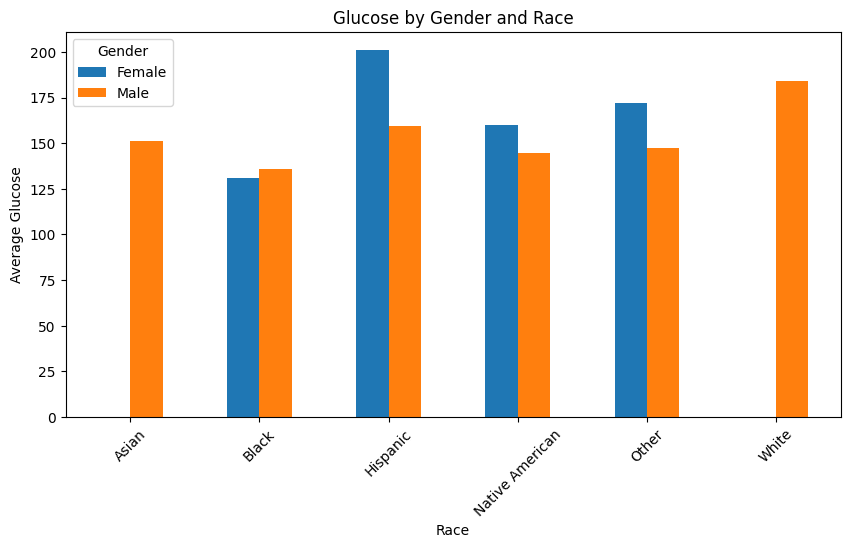

In [15]:
gender_race_glucose.plot(kind='bar', figsize=(10,5))
plt.title("Glucose by Gender and Race")
plt.ylabel("Average Glucose")
plt.xticks(rotation=45)
plt.show()

How does average sleep quality differ between genders?**

This analysis compares the **mean sleep quality score (1–10)** across genders.  
By grouping participants by gender and calculating the average sleep quality, we can observe whether one gender tends to report better or poorer sleep.

In [16]:
import pandas as pd

sleep_by_gender = df.groupby('Gender')['Sleep Quality (1-10)'].mean()

print(sleep_by_gender)

Gender
Female    5.941123
Male      5.874371
Name: Sleep Quality (1-10), dtype: float64


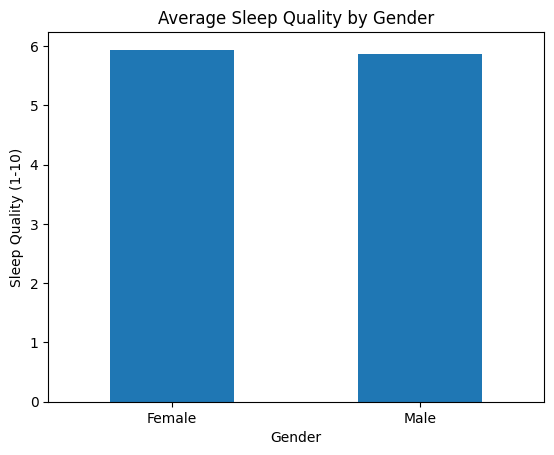

In [17]:
import matplotlib.pyplot as plt

sleep_by_gender.plot(kind='bar')

plt.title("Average Sleep Quality by Gender")
plt.xlabel("Gender")
plt.ylabel("Sleep Quality (1-10)")
plt.xticks(rotation=0)

plt.show()

This analysis examines how many participants experience sleep disturbances and how frequently these disturbances occur.  
The `% with Sleep Disturbances` column is used to compute the distribution, and a pie chart visualizes the proportion of each disturbance level.

In [18]:
print(df['% with Sleep Disturbances'].head())

0    40
1    40
2    40
3    40
4    40
Name: % with Sleep Disturbances, dtype: int64


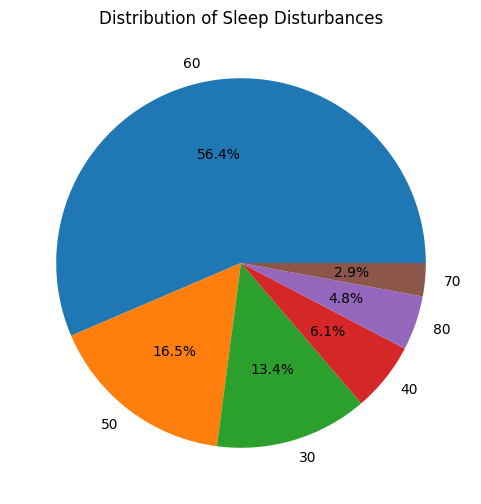

In [19]:
import matplotlib.pyplot as plt

dist_counts = df['% with Sleep Disturbances'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(dist_counts, labels=dist_counts.index, autopct='%1.1f%%')

plt.title("Distribution of Sleep Disturbances")
plt.show()

### **Q. What is the relationship between basal insulin rate and heart rate?**

This analysis explores whether basal insulin delivery rate is associated with changes in heart rate.  
A scatter plot is used to visualize the relationship between the two continuous variables.

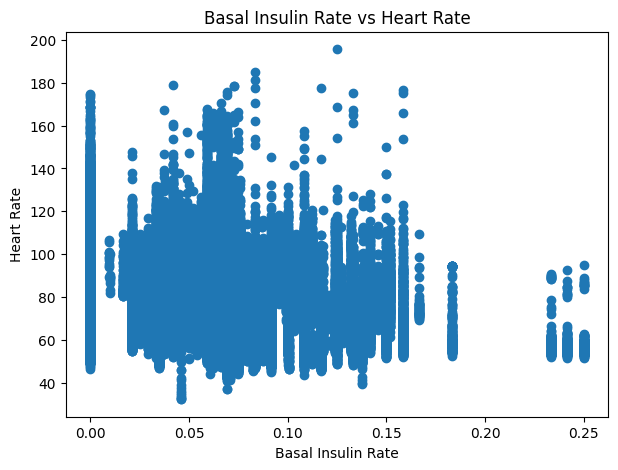

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(df['basal_rate'], df['heart_rate'])

plt.title("Basal Insulin Rate vs Heart Rate")
plt.xlabel("Basal Insulin Rate")
plt.ylabel("Heart Rate")

plt.show()

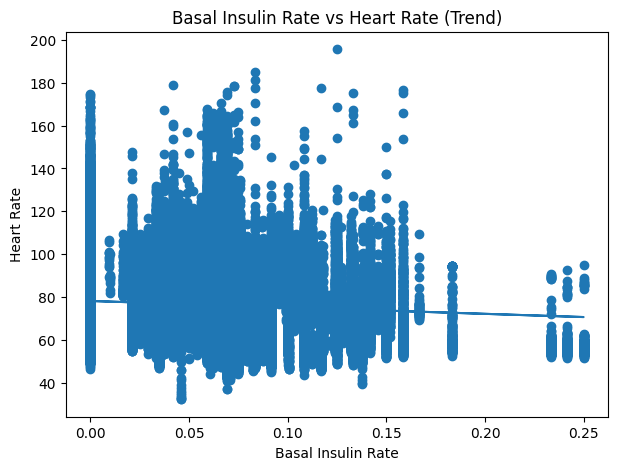

In [21]:
import numpy as np
import matplotlib.pyplot as plt

x = df['basal_rate']
y = df['heart_rate']

plt.figure(figsize=(7,5))
plt.scatter(x, y)

# trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("Basal Insulin Rate vs Heart Rate (Trend)")
plt.xlabel("Basal Insulin Rate")
plt.ylabel("Heart Rate")

plt.show()

In [22]:
correlation = df['basal_rate'].corr(df['heart_rate'])
print("Correlation:", correlation)

Correlation: -0.0697204699169266


What is the distribution of glucose categories in the dataset?**

Participants are classified into three clinical glucose categories:

- **Normal**: Glucose < 100  
- **Prediabetic**: 100–125  
- **Diabetic**: ≥ 126  

A donut chart is used to visualize the proportion of participants in each category, making it easy to compare the relative sizes of the groups.

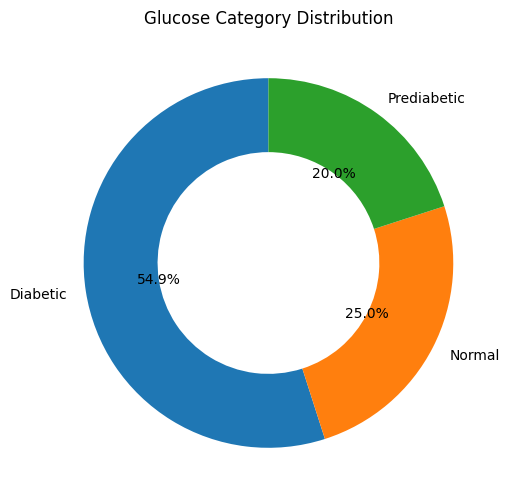

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# assume your dataframe is df and glucose column is 'glucose'

def classify_glucose(g):
    if g < 100:
        return "Normal"
    elif g < 126:
        return "Prediabetic"
    else:
        return "Diabetic"

df["Glucose_Category"] = df["glucose"].apply(classify_glucose)

# count categories
counts = df["Glucose_Category"].value_counts()

# donut chart
plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}  # makes it donut shape
)

plt.title("Glucose Category Distribution")
plt.show()

What is the distribution of glucose risk categories in the dataset?**

Participants are classified into three clinical glucose categories:

- **Normal**: Glucose < 100  
- **Prediabetic**: 100–125  
- **Diabetic**: ≥ 126  

A bar chart is used to show how many participants fall into each category, helping identify the overall metabolic risk distribution in the dataset.

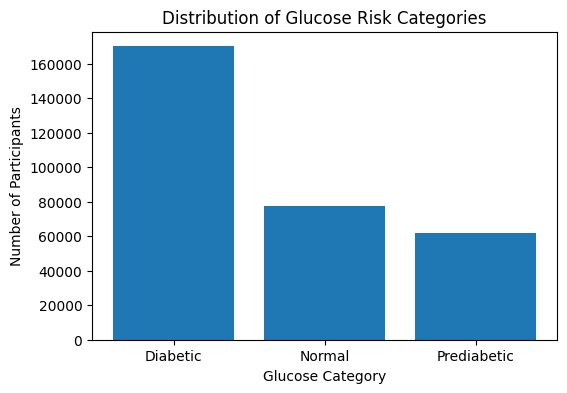

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Create glucose categories
def categorize(glucose):
    if glucose < 100:
        return "Normal"
    elif glucose < 126:
        return "Prediabetic"
    else:
        return "Diabetic"

df["Glucose_Category"] = df["glucose"].apply(categorize)

# Count each category
counts = df["Glucose_Category"].value_counts().sort_index()

# Bar chart
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)

plt.title("Distribution of Glucose Risk Categories")
plt.xlabel("Glucose Category")
plt.ylabel("Number of Participants")
plt.show()